In [9]:
import joblib

model = joblib.load("model.pkl")

X_new = new_df.drop("target", axis=1)
y_new = new_df["target"]

model.partial_fit(X_new, y_new)

joblib.dump(model, "model.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'model.pkl'

In [14]:
"""
Sentiment Analysis Project (Simple End-to-End)

NOTE:
This is a starter template with simple code and comments.
Install:
pip install pandas nltk scikit-learn textblob emoji contractions xgboost matplotlib
"""

import re
import string
import pandas as pd
import nltk
import emoji
import contractions
 

from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
 

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
 
import matplotlib.pyplot as plt
 

nltk.download("stopwords")
nltk.download("wordnet")
 
# Create sample dataset
# -------------------------
pos = ["I love this product 😊","Amazing service!","Excellent quality","Very happy","Worth buying"]*10
neg = ["I hate this product 😡","Bad service","Poor quality","Very disappointed","Waste of money"]*10
 

[nltk_data] Downloading package stopwords to C:\Users\Ashwini
[nltk_data]     Wandre\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\Ashwini
[nltk_data]     Wandre\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [18]:
reviews = pos + neg
labels = [1]*50 + [0]*50

reviews = pos + neg
df = pd.DataFrame({"review":reviews,"sentiment":labels})
df.shape

(100, 2)

In [25]:
 

 

df = pd.DataFrame({"review":reviews,"sentiment":labels})
df.to_csv("sentiment_data.csv",index=False)
 

stop_words = set(stopwords.words("english"))
lemm = WordNetLemmatizer()

 

def clean_text(text):
    text = text.lower()
    text = emoji.demojize(text, delimiters=(" "," "))
    text = contractions.fix(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text) 
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\S+@\S+", "EMAIL", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("","",string.punctuation))
    text = str(TextBlob(text).correct())
    words=[]
    for w in text.split():
        if w not in stop_words and len(w)>2:
            words.append(lemm.lemmatize(w))
    return " ".join(words)
 

df["clean_review"]=df["review"].apply(clean_text)
 
df.to_csv("cleaned_sentiment.csv",index=False)

tfidf=TfidfVectorizer(max_features=100)
X=tfidf.fit_transform(df["clean_review"])
y=df["sentiment"]

 
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)
 
log=LogisticRegression(max_iter=500)
dt=DecisionTreeClassifier(random_state=42)
 

grid=GridSearchCV(dt,{"max_depth":[2,3,5],"criterion":["gini","entropy"]},cv=3)
grid.fit(X_train,y_train)
best_dt=grid.best_estimator_

 
vote=VotingClassifier(
    estimators=[("lr",log),("dt",best_dt)],
    voting="soft"
)

models={
    "Logistic Regression":log,
    "Decision Tree":best_dt,
     
    "Voting":vote
}

    
 


\n Logistic Regression
[[10  0]
 [ 0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



C:\Users\Ashwini Wandre\AppData\Local\Temp\ipykernel_20148\3079763566.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


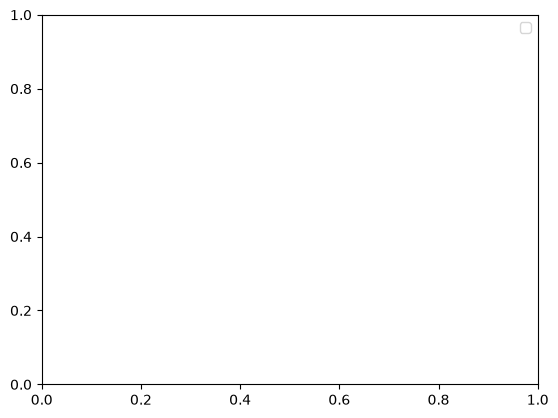

\n Decision Tree
[[10  0]
 [ 0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



C:\Users\Ashwini Wandre\AppData\Local\Temp\ipykernel_20148\3079763566.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


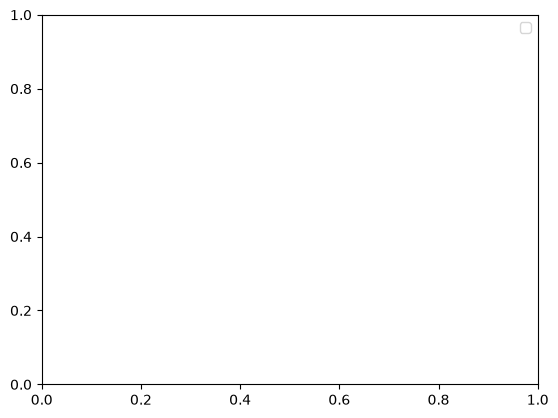

\n Voting
[[10  0]
 [ 0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



C:\Users\Ashwini Wandre\AppData\Local\Temp\ipykernel_20148\3079763566.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


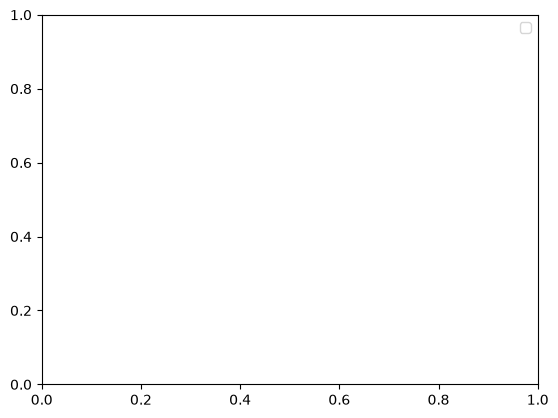

In [26]:

for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    prob=model.predict_proba(X_test)[:,1]
    print("\\n",name)
    print(confusion_matrix(y_test,pred))
    print(classification_report(y_test,pred))
    fpr,tpr,_=roc_curve(y_test,prob)
    score=auc(fpr,tpr)
    plt.figure()
 
    plt.legend()
    plt.show()